# Python：多元线性回归

使用 `statsmodels` 自带的 `longley` 数据集拟合模型。

$$\text{Employed}=\beta_0+\beta_1\text{GNP}+\beta_2\text{Unemployed}+\beta_3\text{Armed.Forces}+\varepsilon.$$

下面的代码单元是自包含的：数据、模型、结果表和诊断图会一次完成。

,Employed,GNPDEFL,GNP,Unemployed,Armed.Forces,POP,YEAR
0,60323.0,83.0,234289.0,2356.0,1590.0,107608.0,1947.0
1,61122.0,88.5,259426.0,2325.0,1456.0,108632.0,1948.0
2,60171.0,88.2,258054.0,3682.0,1616.0,109773.0,1949.0
3,61187.0,89.5,284599.0,3351.0,1650.0,110929.0,1950.0
4,63221.0,96.2,328975.0,2099.0,3099.0,112075.0,1951.0
5,63639.0,98.1,346999.0,1932.0,3594.0,113270.0,1952.0
6,64989.0,99.0,365385.0,1870.0,3547.0,115094.0,1953.0
7,63761.0,100.0,363112.0,3578.0,3350.0,116219.0,1954.0


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
term,,,,,,
const,53306.461188,716.341858,74.414835,2.308062e-17,51745.686357,54867.236019
GNP,0.040788,0.002207,18.484702,3.492346e-10,0.035980,0.045596
Unemployed,-0.796817,0.213403,-3.733862,2.853745e-03,-1.261781,-0.331852
Armed.Forces,-0.482766,0.255160,-1.892013,8.286081e-02,-1.038711,0.073180


                            OLS Regression Results                            
Dep. Variable:               Employed   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     264.4
Date:                Sun, 12 Jul 2026   Prob (F-statistic):           3.19e-11
Time:                        22:16:09   Log-Likelihood:                -119.16
No. Observations:                  16   AIC:                             246.3
Df Residuals:                      12   BIC:                             249.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         5.331e+04    716.342     74.415   

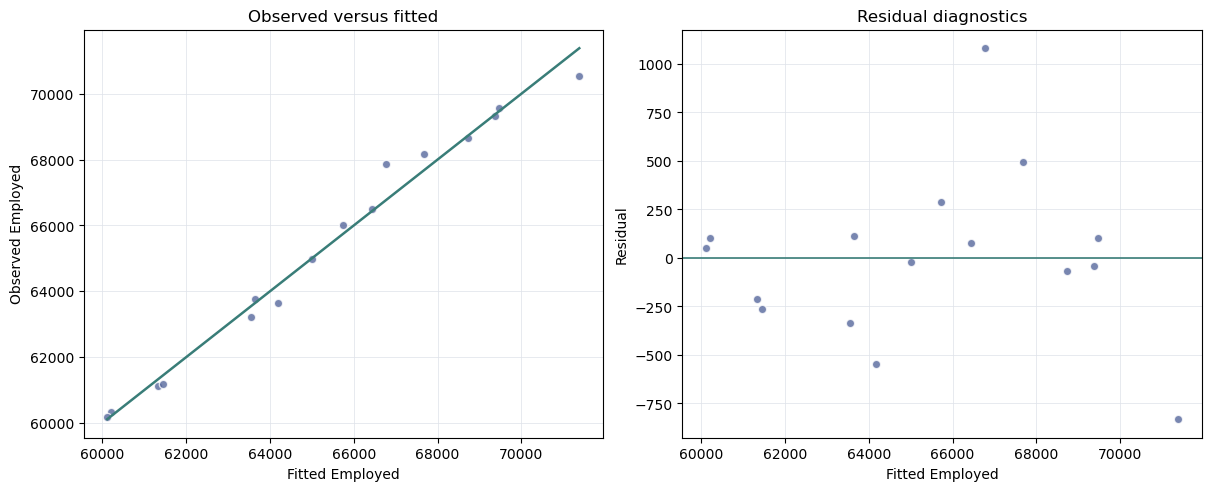

In [1]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display
from statsmodels.datasets import longley

# 加载 statsmodels 自带数据集。不同版本使用缩写列名，先统一为 R 的命名。
data = longley.load_pandas().data.rename(
    columns={
        'TOTEMP': 'Employed',
        'UNEMP': 'Unemployed',
        'ARMED': 'Armed.Forces',
    }
)
display(data.head(8))

# 拟合多元线性回归
predictors = ['GNP', 'Unemployed', 'Armed.Forces']
design = sm.add_constant(data[predictors], has_constant='add')
model = sm.OLS(data['Employed'], design).fit()

display(model.summary2().tables[1].rename_axis('term'))
print(model.summary())

# 生成观测值—拟合值图和残差图
fitted = model.fittedvalues.to_numpy()
observed = data['Employed'].to_numpy()
residuals = model.resid.to_numpy()
lower = min(observed.min(), fitted.min())
upper = max(observed.max(), fitted.max())

figure, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
axes[0].scatter(fitted, observed, color='#52649a', alpha=0.78, edgecolor='white')
axes[0].plot([lower, upper], [lower, upper], color='#397d78', linewidth=1.8)
axes[0].set(title='Observed versus fitted', xlabel='Fitted Employed', ylabel='Observed Employed')

axes[1].axhline(0, color='#397d78', linewidth=1.2)
axes[1].scatter(fitted, residuals, color='#52649a', alpha=0.78, edgecolor='white')
axes[1].set(title='Residual diagnostics', xlabel='Fitted Employed', ylabel='Residual')
for axis in axes:
    axis.grid(color='#dfe3ea', linewidth=0.7, alpha=0.75)
    axis.set_axisbelow(True)
plt.show()

## 结果解释

观测值—拟合值图用于评价整体拟合，残差图用于观察线性与同方差假设是否存在明显偏离。